In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
datos_originales = pd.read_csv("sensor.csv")
datos_originales

,Unnamed: 0,timestamp,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,...,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,machine_status
0,0,2018-04-01 00:00:00,2.465394,47.09201,53.211800,46.310760,634.375000,76.45975,13.41146,16.13136,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
1,1,2018-04-01 00:01:00,2.465394,47.09201,53.211800,46.310760,634.375000,76.45975,13.41146,16.13136,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
2,2,2018-04-01 00:02:00,2.444734,47.35243,53.211800,46.397570,638.888900,73.54598,13.32465,16.03733,...,41.66666,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,241.3194,203.7037,NORMAL
3,3,2018-04-01 00:03:00,2.460474,47.09201,53.168400,46.397568,628.125000,76.98898,13.31742,16.24711,...,40.88541,39.062500,64.81481,51.21528,38.194440,155.9606,66.84028,240.4514,203.1250,NORMAL
4,4,2018-04-01 00:04:00,2.445718,47.13541,53.211800,46.397568,636.458300,76.58897,13.35359,16.21094,...,41.40625,38.773150,65.10416,51.79398,38.773150,158.2755,66.55093,242.1875,201.3889,NORMAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220315,220315,2018-08-31 23:55:00,2.407350,47.69965,50.520830,43.142361,634.722229,64.59095,15.11863,16.65220,...,38.28125,68.287030,52.37268,48.32176,41.087960,212.3843,153.64580,NaN,231.1921,NORMAL
220316,220316,2018-08-31 23:56:00,2.400463,47.69965,50.564240,43.142361,630.902771,65.83363,15.15480,16.70284,...,38.28125,66.840280,50.63657,48.03241,40.798610,213.8310,156.25000,NaN,231.1921,NORMAL
220317,220317,2018-08-31 23:57:00,2.396528,47.69965,50.520830,43.142361,625.925903,67.29445,15.08970,16.70284,...,39.06250,65.393520,48.90046,48.03241,40.798610,217.3032,155.38190,NaN,232.0602,NORMAL
220318,220318,2018-08-31 23:58:00,2.406366,47.69965,50.520832,43.142361,635.648100,65.09175,15.11863,16.56539,...,40.62500,64.236110,47.74306,48.32176,40.509258,222.5116,153.93520,NaN,234.0856,NORMAL


In [62]:
print("Nombres de las columnas:")
print(datos_originales.columns.tolist())

Nombres de las columnas:
['Unnamed: 0', 'timestamp', 'sensor_00', 'sensor_01', 'sensor_02', 'sensor_03', 'sensor_04', 'sensor_05', 'sensor_06', 'sensor_07', 'sensor_08', 'sensor_09', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21', 'sensor_22', 'sensor_23', 'sensor_24', 'sensor_25', 'sensor_26', 'sensor_27', 'sensor_28', 'sensor_29', 'sensor_30', 'sensor_31', 'sensor_32', 'sensor_33', 'sensor_34', 'sensor_35', 'sensor_36', 'sensor_37', 'sensor_38', 'sensor_39', 'sensor_40', 'sensor_41', 'sensor_42', 'sensor_43', 'sensor_44', 'sensor_45', 'sensor_46', 'sensor_47', 'sensor_48', 'sensor_49', 'sensor_50', 'sensor_51', 'machine_status']


In [63]:
# Veo el resumen de las columnas y si hay vacíos
print("Resumen de la tabla")
datos_originales.info()


Resumen de la tabla
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220320 entries, 0 to 220319
Data columns (total 55 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Unnamed: 0      220320 non-null  int64  
 1   timestamp       220320 non-null  object 
 2   sensor_00       210112 non-null  float64
 3   sensor_01       219951 non-null  float64
 4   sensor_02       220301 non-null  float64
 5   sensor_03       220301 non-null  float64
 6   sensor_04       220301 non-null  float64
 7   sensor_05       220301 non-null  float64
 8   sensor_06       215522 non-null  float64
 9   sensor_07       214869 non-null  float64
 10  sensor_08       215213 non-null  float64
 11  sensor_09       215725 non-null  float64
 12  sensor_10       220301 non-null  float64
 13  sensor_11       220301 non-null  float64
 14  sensor_12       220301 non-null  float64
 15  sensor_13       220301 non-null  float64
 16  sensor_14       220299 non-null  flo

In [64]:
print("Datos vacíos")
nulos_columna= datos_originales.isnull().sum()
print(nulos_columna.sort_values(ascending=False).head(5))
print("-"*40)

Datos vacíos
sensor_15    220320
sensor_50     77017
sensor_51     15383
sensor_00     10208
sensor_07      5451
dtype: int64
----------------------------------------


In [65]:
#Feature Engineering
#Primero voy a traducir porque el inglés no es lo mio y a final de cuentas broken y recovering son una falla y es lo mismo
#Así que usare lambda para que recorra la columna y asi si no dice normal va a escribir Falla y si dice normal escribe estable
datos_originales["estado_motor"] = datos_originales["machine_status"].apply(lambda x: "Falla" if x!= "NORMAL" else "Estable")

#Hay datos que en verdad no sirven para nada proque cuando revisé el contenido del dataset estaban vacios (como por ejemplo el sensor_15) o casi todos eran vacios
#o son datos que no me sirven por como están hechos, por ejemplo timestamp es un texto con fechas, no me sirve así que voy a hacer una "limpieza previa" solo porque son muchos datos y es innecesario trabajar cosas que no usaré
datos=datos_originales.drop(columns=["Unnamed: 0", "timestamp", "sensor_15", "sensor_50", "machine_status"], errors="ignore")

#Si algún otro sensor se apagó un microsegundo y dejó una celda vacía (las que dicen NaN), se va a rellenar con 0 para que no dé error y en series de tiempo los vacios se rellenan con el último valor válido (ffill)
datos= datos.fillna(method="ffill").fillna(0)

C:\Users\samir\AppData\Local\Temp\ipykernel_18016\1000565232.py:11: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  datos= datos.fillna(method="ffill").fillna(0)


In [66]:

#En lugar de darle a la máquina 4 sensores de vibración por separado tomamos esos 4 sensores, los sumamos y los dividimos por 4 (.mean) calculando horizontalmte (axis=1)
#Guardo esto en una columna nueva llamada "vibración_promedio" 
datos["vibracion_promedio"] = datos [["sensor_00", "sensor_01", "sensor_02", "sensor_03"]].mean(axis=1)
print(datos["estado_motor"].value_counts())

estado_motor
Estable    205836
Falla       14484
Name: count, dtype: int64


C:\Users\samir\AppData\Local\Temp\ipykernel_18016\1440417055.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=datos, x="estado_motor", palette="Set2")


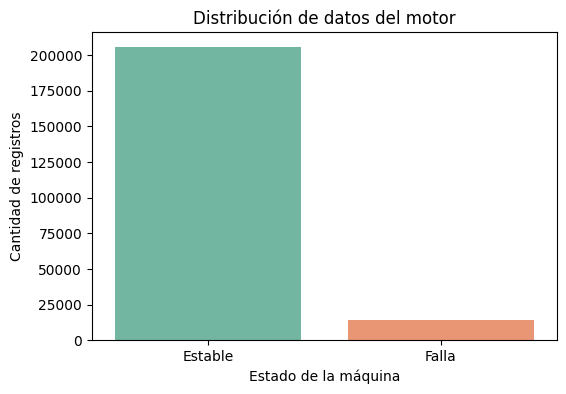

In [67]:
#Visualización
#crear lienzo en blanco para el gráfico
plt.figure(figsize=(6, 4))
#Dibujar un gráfico de barras contando los estables e intestables
sns.countplot(data=datos, x="estado_motor", palette="Set2")

plt.title("Distribución de datos del motor")
plt.xlabel("Estado de la máquina")
plt.ylabel("Cantidad de registros")

plt.show()

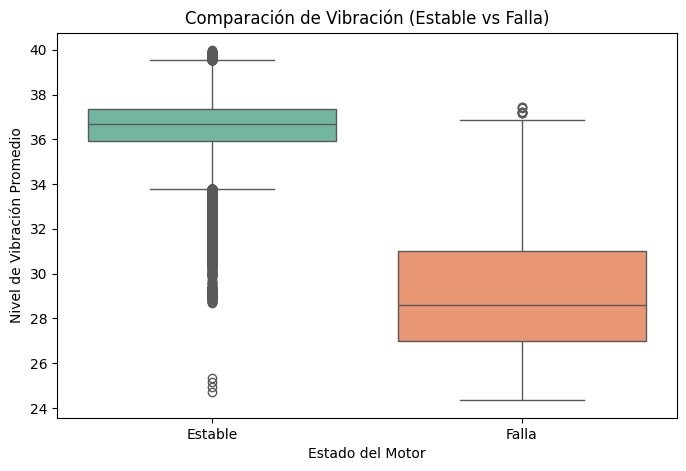

In [68]:
#boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=datos, x="estado_motor", y="vibracion_promedio", hue="estado_motor", palette="Set2", legend=False)
plt.title("Comparación de Vibración (Estable vs Falla)")
plt.ylabel("Nivel de Vibración Promedio")
plt.xlabel("Estado del Motor")
plt.show()

In [80]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Primero separo las pistas (X) de las respuestas (y)
#Quito las respuestas. el error="ignore" es por si ya las habia borrado antes para que no falle 
X = datos.drop(columns=["estado_motor", "machine_status"],errors="ignore")
y = datos["estado_motor"]

#Calculo donde están el 80% de mi tabla
split_point = int(len(datos) * 0.7)

# Corto la tabla usando índices (iloc) para que sea un corte limpio
X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

#Escalar los datos
scaler = StandardScaler()

#El modelo "aprende" la escala con los datos de estudio y los transforma
X_train_escalado = scaler.fit_transform(X_train)

#Aplicamos la misma regla a los datos de prueba
X_test_escalado = scaler.transform(X_test)

print("Tenemos", X_train_escalado.shape[0],"escenarios para estudiar")
print("y", X_test_escalado.shape[0], "escenarios ocultos para la prueba final")


Tenemos 154224 escenarios para estudiar
y 66096 escenarios ocultos para la prueba final


In [81]:
#Feature Selection (información mutua) 
from sklearn.feature_selection import mutual_info_classif

#Calcular la importancia de cada feature
puntajes_informacion = mutual_info_classif(X_train_escalado, y_train, random_state=42)

#Tabla para visualizar el ranking de importancia
tabla_importancia = pd.DataFrame({
    "Sensor/variable": X.columns,
    "Información aportada": puntajes_informacion
}).sort_values(by="Información aportada", ascending=False)

display(tabla_importancia)

,Sensor/variable,Información aportada
0,sensor_00,0.305166
4,sensor_04,0.297169
10,sensor_10,0.287166
11,sensor_11,0.286423
5,sensor_05,0.282722
6,sensor_06,0.280531
12,sensor_12,0.280016
50,vibracion_promedio,0.275397
13,sensor_13,0.270265
7,sensor_07,0.265359


In [82]:
#Filtrar ruido

#Guardar los nombres de las variables que sacaron más de 0
columnas_utiles = tabla_importancia[tabla_importancia["Información aportada"] > 0]["Sensor/variable"].tolist()

print("Nos quedamos solo con:", columnas_utiles)



Nos quedamos solo con: ['sensor_00', 'sensor_04', 'sensor_10', 'sensor_11', 'sensor_05', 'sensor_06', 'sensor_12', 'vibracion_promedio', 'sensor_13', 'sensor_07', 'sensor_08', 'sensor_48', 'sensor_09', 'sensor_49', 'sensor_40', 'sensor_38', 'sensor_02', 'sensor_01', 'sensor_39', 'sensor_46', 'sensor_51', 'sensor_41', 'sensor_45', 'sensor_03', 'sensor_47', 'sensor_44', 'sensor_43', 'sensor_42', 'sensor_26', 'sensor_25', 'sensor_36', 'sensor_28', 'sensor_23', 'sensor_29', 'sensor_30', 'sensor_35', 'sensor_14', 'sensor_34', 'sensor_22', 'sensor_27', 'sensor_32', 'sensor_16', 'sensor_24', 'sensor_31', 'sensor_19', 'sensor_21', 'sensor_20', 'sensor_17', 'sensor_33', 'sensor_18', 'sensor_37']


In [84]:
#Buscar en qué posición númerica están esas columnas útiles
indices_utiles = [i for i, p in enumerate(puntajes_informacion) if p > 0]

#Recortamos nuestras matrices de estudio y prueba para quedarnos solo con las columnas útiles
X_train_filtrado = X_train_escalado[:, indices_utiles]
X_test_filtrado = X_test_escalado[:, indices_utiles]

print(f"Pasamos de {X_train_escalado.shape[1]} a {X_train_filtrado.shape[1]} columnas.")

Pasamos de 51 a 51 columnas.


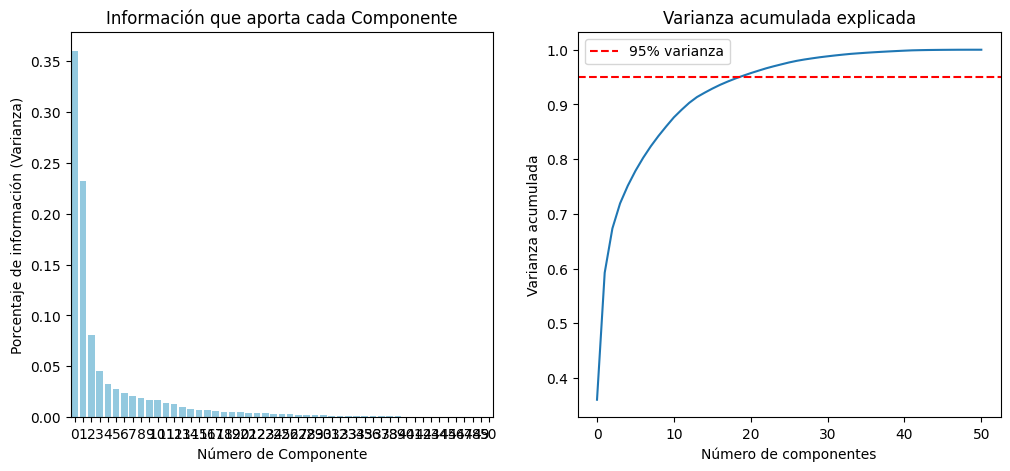

In [85]:
#PCA
from sklearn.decomposition import PCA
import numpy as np

#PCA se entrena con los datos ya filtrados
pca = PCA()
pca.fit(X_train_filtrado)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(
    x=np.arange(len(pca.explained_variance_ratio_)), 
    y=pca.explained_variance_ratio_, 
    color="skyblue"
)
plt.title("Información que aporta cada Componente")
plt.xlabel("Número de Componente")
plt.ylabel("Porcentaje de información (Varianza)")

plt.subplot(1, 2, 2)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.axhline(y=0.95, color="Red", linestyle="--", label="95% varianza")
plt.title("Varianza acumulada explicada")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.legend()
plt.show()

In [86]:
#Compresión final
pca_final = PCA(n_components=0.95)
X_train_pca = pca_final.fit_transform(X_train_escalado[:,indices_utiles])
X_test_pca = pca_final.transform(X_test_escalado[:, indices_utiles])

In [87]:
#Usando Regresión Logistica
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score
from sklearn.model_selection import cross_val_score

#Llamo al modelo
modelo_logistico = LogisticRegression(class_weight="balanced", max_iter=1000)

#Lo hago estudiar los 8.000 datos
modelo_logistico.fit(X_train_pca, y_train)

#Validación cruzada (control de Overfitting)
#Tomo 5 pruebas distintas a los datos de estudio
notas_cv_log = cross_val_score(modelo_logistico, X_train_pca, y_train, cv=5)
print(f"Validación cruzada (5 pruebas): {notas_cv_log.mean()*100:.2f}% de exactitud promedio")

#Testeo, le pido que adivine la estabilidad de los 2.000 datos ocultos
predicciones_log = modelo_logistico.predict(X_test_pca)
probabilidades_log = modelo_logistico.predict_proba(X_test_pca)[:,1] #esto es necesario para ROC-AUC

#Comparo sus adivinanzas con las respuestas reales
precision_log = accuracy_score(y_test, predicciones_log)
print(f"El modelo predijo la estabilidad con un {precision_log * 100:.2f}% de exactitud.\n")

#Reporte completo de métricas
print("\nReporte de clasisificación detallado:")
print(classification_report(y_test, predicciones_log))

#ROC-AUC
roc_auc_log = roc_auc_score(y_test, probabilidades_log)
print(f"Puntaje ROC.AUC: {roc_auc_log:.4f}\n")


Validación cruzada (5 pruebas): 96.89% de exactitud promedio
El modelo predijo la estabilidad con un 99.76% de exactitud.


Reporte de clasisificación detallado:
              precision    recall  f1-score   support

     Estable       1.00      1.00      1.00     66020
       Falla       0.31      0.91      0.46        76

    accuracy                           1.00     66096
   macro avg       0.65      0.95      0.73     66096
weighted avg       1.00      1.00      1.00     66096

Puntaje ROC.AUC: 0.9976



<Figure size 600x400 with 0 Axes>

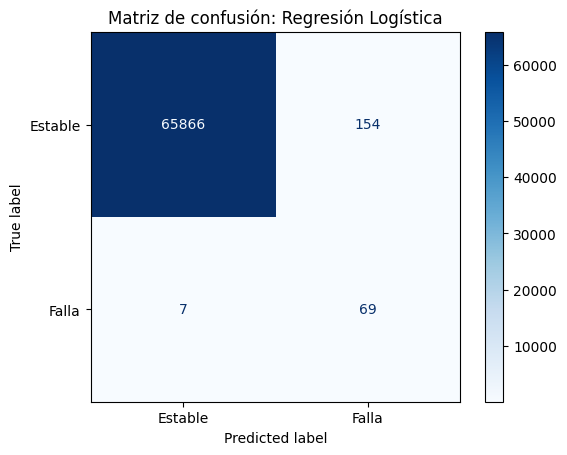

In [88]:
#Matriz de confusión con los aciertos y errores
matriz_log = confusion_matrix(y_test, predicciones_log)

grafico_log = ConfusionMatrixDisplay(confusion_matrix=matriz_log, display_labels=modelo_logistico.classes_)

plt.figure(figsize=(6,4))
grafico_log.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusión: Regresión Logística")
plt.show()

In [89]:
#Ahora usaré KNN
from sklearn.neighbors import KNeighborsClassifier

#El modelo mirará los 5 vecinos más cercanos
modelo_knn = KNeighborsClassifier(n_neighbors=5, weights="distance")
modelo_knn.fit(X_train_pca, y_train)

#Validación cruzada
notas_cv_knn = cross_val_score(modelo_knn, X_train_pca, y_train, cv=5)
print(f"Validación cruzarada (5 pruebas): {notas_cv_knn.mean()*100:.2f}% de exactitud promedio")

#testeo
predicciones_knn = modelo_knn.predict(X_test_pca)
probabilidades_knn = modelo_knn.predict_proba(X_test_pca)[:,1]

#metricas
precision_knn = accuracy_score(y_test, predicciones_knn)
print(f"El modelo predijo la estabilidad con un {precision_knn * 100:.2f}% de exactitud.\n")

print(f"\nReporte de clasificación detallado:")
print(classification_report(y_test, predicciones_knn))

#ROC-AUC
roc_auc_knn = roc_auc_score(y_test, probabilidades_knn)
print(f"Puntaje ROC-AUC: {roc_auc_knn: .4f}\n")

Validación cruzarada (5 pruebas): 97.75% de exactitud promedio
El modelo predijo la estabilidad con un 99.59% de exactitud.


Reporte de clasificación detallado:
              precision    recall  f1-score   support

     Estable       1.00      1.00      1.00     66020
       Falla       0.15      0.55      0.24        76

    accuracy                           1.00     66096
   macro avg       0.57      0.77      0.62     66096
weighted avg       1.00      1.00      1.00     66096

Puntaje ROC-AUC:  0.8004



<Figure size 600x400 with 0 Axes>

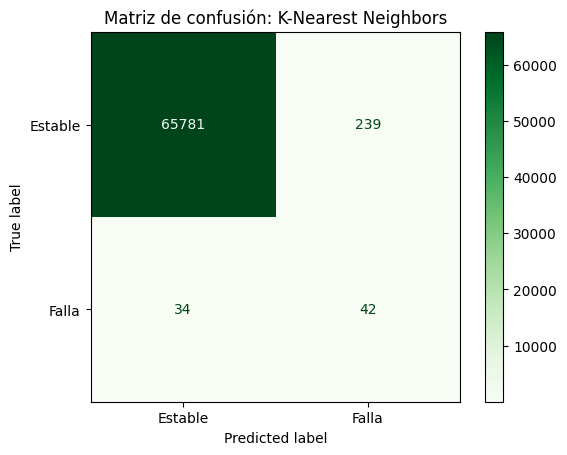

In [90]:
#matriz confusion
matriz_knn = confusion_matrix(y_test, predicciones_knn)
grafico_knn = ConfusionMatrixDisplay(confusion_matrix=matriz_knn, display_labels=modelo_knn.classes_)

plt.figure(figsize=(6, 4))
grafico_knn.plot(cmap="Greens", values_format="d")
plt.title("Matriz de confusión: K-Nearest Neighbors")
plt.show()

In [91]:
print("Comparación de modelos")
print(f"Exactitud Regresión Logística: {precision_log*100:.2f}%")
print(f"Exactitud K-Nearest Neighbors: {precision_knn*100:.2f}%")

Comparación de modelos
Exactitud Regresión Logística: 99.76%
Exactitud K-Nearest Neighbors: 99.59%


In [ ]:
#No entiendo por qué predice tan bien, lo he revisado mil veces